<a href="https://colab.research.google.com/github/Thalapathi26/AI_ML/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

In [ ]:
vocab_size = 10000  # top 10k words

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

In [ ]:
model = Sequential()

# Convert word indices into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))

# RNN Layer
model.add(SimpleRNN(64, activation='tanh'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.6413 - loss: 0.6103 - val_accuracy: 0.7556 - val_loss: 0.5086
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8218 - loss: 0.4023 - val_accuracy: 0.6646 - val_loss: 0.6051
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8856 - loss: 0.2924 - val_accuracy: 0.7998 - val_loss: 0.4653
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.9322 - loss: 0.1783 - val_accuracy: 0.8242 - val_loss: 0.5258
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9768 - loss: 0.0700 - val_accuracy: 0.7908 - val_loss: 0.6521


In [ ]:
import matplotlib.pyplot as plt

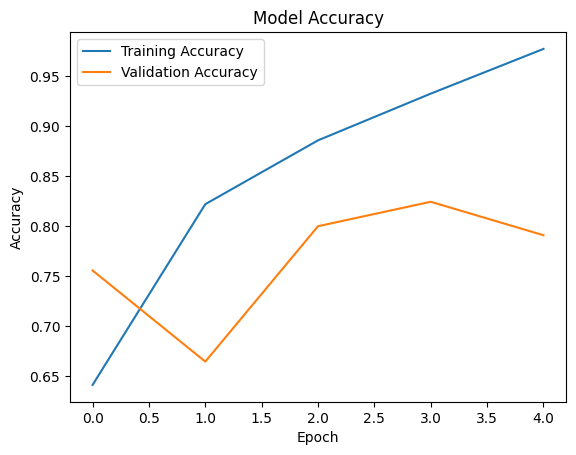

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7809 - loss: 0.6673
Test Accuracy: 0.7809200286865234


In [ ]:
predictions = model.predict(x_test[:5])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
[[6.9108763e-04]
 [9.9559307e-01]
 [1.7611176e-01]
 [1.9967918e-01]
 [7.3459905e-01]]


In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Adjust word index to account for special tokens (padding, start, unknown)
def preprocess_text(text):
    words = text.lower().split()
    encoded_review = []
    for word in words:
        # Get word index, default to 1 (unknown word token) if not found
        # IMDB dataset maps unknown to 2, padding to 0, start to 1.
        # Adjusting word indices to start from 3 for actual words.
        encoded_review.append(word_index.get(word, 2) + 3)
    return encoded_review

def predict_review(text):
    # Preprocess the input text
    encoded_input = preprocess_text(text)
    # Pad the sequence to the model's expected input length
    padded_input = pad_sequences([encoded_input], maxlen=max_length)

    # Make a prediction
    prediction = model.predict(padded_input)
    return prediction[0][0]

# Example usage:
user_review_positive = "This movie was absolutely fantastic! I loved every single moment of it. The acting was superb and the story was captivating."
user_review_negative = "This movie was terrible. A complete waste of time. The plot was boring and the acting was awful."

print(f"Prediction for positive review: {predict_review(user_review_positive):.4f} (1 = positive, 0 = negative)")
print(f"Prediction for negative review: {predict_review(user_review_negative):.4f} (1 = positive, 0 = negative)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction for positive review: 0.9125 (1 = positive, 0 = negative)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction for negative review: 0.0141 (1 = positive, 0 = negative)
